# Expedia Hack-AI-Thon Review Gap Analysis

This notebook turns the provided Expedia-style hotel review data into a practical analysis pack for the MVP and the pitch deck.

It focuses on four questions:

1. Where is the current review data rich, sparse, or stale?
2. Which review topics appear to matter most to travelers?
3. Which topics are under-covered by the current structured review flow?
4. Which property-specific questions should an adaptive review product ask first?

All figures and tables are saved into `analysis_outputs/` so they can be reused directly in slides.


## Why This Analysis Matters

The competition prompt is not asking for a generic review dashboard. It is asking for a product that can identify **what information is missing or stale** and then ask the guest **1-2 low-friction, high-value follow-up questions**.

So the analysis below is organized to support that exact product logic:

- data completeness and freshness
- topic importance and pain points
- structured-rating blind spots
- property-level question opportunities for the MVP


In [1]:
from pathlib import Path
import ast
import json
import math
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown


DATA_DIR = Path(".")
OUTPUT_DIR = DATA_DIR / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

PALETTE = {
    "navy": "#0B1F3A",
    "blue": "#2878B5",
    "sky": "#67A9CF",
    "teal": "#1B998B",
    "gold": "#F3A712",
    "red": "#D1495B",
    "gray": "#6B7280",
    "light_gray": "#E5E7EB",
    "dark_gold": "#C68800",
}

plt.style.use("default")
plt.rcParams.update(
    {
        "figure.figsize": (11, 6),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "font.size": 10,
    }
)

pd.options.display.max_colwidth = 140
pd.options.display.float_format = lambda x: f"{x:,.3f}"


def savefig(fig, name: str):
    fig.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight", dpi=220)
    fig.savefig(OUTPUT_DIR / f"{name}.svg", bbox_inches="tight")
    plt.show()


def pct(value: float) -> str:
    return f"{value:.1%}"


def safe_list(value):
    if pd.isna(value) or value == "":
        return []
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return [str(item) for item in parsed]
        return [str(parsed)]
    except Exception:
        return [str(value)]


def clean_text(value: str) -> str:
    if pd.isna(value):
        return ""
    text = str(value).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


def bool_from_keywords(text: str, keywords):
    text = clean_text(text)
    return any(keyword in text for keyword in keywords)


print(f"Charts/tables will be written to: {OUTPUT_DIR.resolve()}")


Charts/tables will be written to: C:\VS Code\Projects\Wharton Hack-AI-Thon\analysis_outputs


In [2]:
description = pd.read_csv(DATA_DIR / "Description_PROC.csv")
reviews_raw = pd.read_csv(DATA_DIR / "Reviews_PROC.csv")

rating_frame = reviews_raw["rating"].apply(json.loads).apply(pd.Series)
rating_frame = rating_frame.apply(pd.to_numeric, errors="coerce").fillna(0)
rating_frame.columns = [f"rating_{col}" for col in rating_frame.columns]

reviews = pd.concat([reviews_raw.drop(columns=["rating"]), rating_frame], axis=1)
reviews["acquisition_date"] = pd.to_datetime(reviews["acquisition_date"], errors="coerce")
reviews["review_title"] = reviews["review_title"].fillna("").astype(str)
reviews["review_text"] = reviews["review_text"].fillna("").astype(str)
reviews["review_full_text"] = (reviews["review_title"] + " " + reviews["review_text"]).str.strip()
reviews["clean_text"] = reviews["review_full_text"].apply(clean_text)
reviews["has_title"] = reviews["review_title"].str.strip().ne("")
reviews["has_text"] = reviews["review_text"].str.strip().ne("")
reviews["word_count"] = reviews["review_full_text"].str.split().str.len().fillna(0).astype(int)
reviews["under_20_words"] = reviews["word_count"] < 20
reviews["under_50_words"] = reviews["word_count"] < 50
reviews["non_ascii_text"] = reviews["review_full_text"].apply(
    lambda value: any(ord(ch) > 127 for ch in value) if value else False
)
reviews["review_month"] = reviews["acquisition_date"].dt.to_period("M").dt.to_timestamp()
reviews["overall_rating"] = reviews["rating_overall"].replace(0, np.nan)
reviews["rating_segment"] = pd.cut(
    reviews["overall_rating"],
    bins=[0, 2, 3, 5],
    labels=["low", "mid", "high"],
    include_lowest=True,
)

description["guestrating_avg_expedia"] = pd.to_numeric(
    description["guestrating_avg_expedia"], errors="coerce"
)
description["star_rating"] = pd.to_numeric(description["star_rating"], errors="coerce")
description["popular_amenities"] = description["popular_amenities_list"].apply(safe_list)

amenity_cols = [col for col in description.columns if col.startswith("property_amenity_")]
description["all_amenity_tokens"] = description["popular_amenities"].copy()
for col in amenity_cols:
    description[col] = description[col].apply(safe_list)
    description["all_amenity_tokens"] = description["all_amenity_tokens"] + description[col]

description["amenity_text"] = description["all_amenity_tokens"].apply(
    lambda items: " ".join(map(str, items)).lower()
)
description["pet_policy_clean"] = description["pet_policy"].fillna("").str.lower()
description["children_policy_clean"] = (
    description["children_and_extra_bed_policy"].fillna("").str.lower()
)
description["property_label"] = description.apply(
    lambda row: f"{row['city']}, {row['country']} ({row['eg_property_id'][:8]})", axis=1
)

merged = reviews.merge(
    description[
        [
            "eg_property_id",
            "property_label",
            "city",
            "province",
            "country",
            "guestrating_avg_expedia",
            "star_rating",
            "amenity_text",
            "pet_policy_clean",
            "children_policy_clean",
        ]
    ],
    on="eg_property_id",
    how="left",
)

analysis_start = reviews["acquisition_date"].min()
analysis_end = reviews["acquisition_date"].max()
recent_180_cutoff = analysis_end - pd.Timedelta(days=180)
recent_365_cutoff = analysis_end - pd.Timedelta(days=365)

print(f"Descriptions: {description.shape}")
print(f"Reviews: {reviews.shape}")
print(f"Review date range: {analysis_start.date()} to {analysis_end.date()}")


C:\Users\alanm\AppData\Local\Temp\ipykernel_47640\2569652568.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  reviews["acquisition_date"] = pd.to_datetime(reviews["acquisition_date"], errors="coerce")


Descriptions: (13, 37)
Reviews: (5999, 31)
Review date range: 2023-02-06 to 2026-02-06


In [3]:
overview_metrics = pd.DataFrame(
    [
        ("Properties in description file", description["eg_property_id"].nunique()),
        ("Properties represented in reviews", reviews["eg_property_id"].nunique()),
        ("Total reviews", len(reviews)),
        ("Text reviews", int(reviews["has_text"].sum())),
        ("Properties with any review in last 365 days", int((reviews.groupby("eg_property_id")["acquisition_date"].max() >= recent_365_cutoff).sum())),
        ("Earliest review date", analysis_start.date()),
        ("Latest review date", analysis_end.date()),
    ],
    columns=["Metric", "Value"],
)

property_summary = (
    merged.groupby(
        ["eg_property_id", "property_label", "city", "country", "guestrating_avg_expedia", "star_rating"],
        as_index=False,
    )
    .agg(
        review_count=("eg_property_id", "size"),
        first_review=("acquisition_date", "min"),
        latest_review=("acquisition_date", "max"),
        recent_180_reviews=("acquisition_date", lambda s: int((s >= recent_180_cutoff).sum())),
        recent_365_reviews=("acquisition_date", lambda s: int((s >= recent_365_cutoff).sum())),
        avg_overall_rating=("overall_rating", "mean"),
        text_review_share=("has_text", "mean"),
        short_review_share=("under_20_words", "mean"),
        non_ascii_share=("non_ascii_text", "mean"),
    )
    .sort_values("review_count", ascending=False)
)

property_summary["days_since_latest_review"] = (
    analysis_end - property_summary["latest_review"]
).dt.days

overview_metrics.to_csv(OUTPUT_DIR / "overview_metrics.csv", index=False)
property_summary.to_csv(OUTPUT_DIR / "property_summary.csv", index=False)

display(Markdown("## Portfolio Snapshot"))
display(overview_metrics)
display(property_summary)


## Portfolio Snapshot

,Metric,Value
0,Properties in description file,13
1,Properties represented in reviews,13
2,Total reviews,5999
3,Text reviews,4258
4,Properties with any review in last 365 days,12
5,Earliest review date,2023-02-06
6,Latest review date,2026-02-06


,eg_property_id,property_label,city,country,guestrating_avg_expedia,star_rating,review_count,first_review,latest_review,recent_180_reviews,recent_365_reviews,avg_overall_rating,text_review_share,short_review_share,non_ascii_share,days_since_latest_review
0,3216b1b7885bffdb336265a8de7322ba0cd477cfb3d4f99d19acf488f76a1941,"Bell Gardens, United States (3216b1b7)",Bell Gardens,United States,8.400,2.000,1094,2023-02-08,2026-02-06,133,309,3.994,0.631,0.770,0.107,0
8,ff26cdda236b233f7c481f0e896814075ac6bed335e162e0ff01d5491343f838,"Frisco, United States (ff26cdda)",Frisco,United States,9.200,3.500,1065,2023-02-14,2026-02-05,104,239,4.437,0.673,0.756,0.088,1
4,db38b19b897dbece3e34919c662b3fd66d23b615395d11fb69264dd3a9b17723,"Broomfield, United States (db38b19b)",Broomfield,United States,9.200,4.000,1006,2023-02-14,2026-02-04,98,200,4.373,0.667,0.696,0.083,2
2,7d027ef72c02eaa17af3c993fd5dba50d17b41a6280389a46c13c7e2c32a5b06,"Ocala, United States (7d027ef7)",Ocala,United States,6.600,2.500,765,2023-02-06,2026-02-06,54,94,3.463,0.698,0.617,0.101,0
7,fa014137b3ea9af6a90c0a86a1d099e46f7e56d6eb33db1ad1ec4bdac68c3caa,"Monterey, United States (fa014137)",Monterey,United States,8.800,2.500,728,2023-02-13,2026-02-05,65,123,4.370,0.750,0.629,0.099,1
6,f2d8d9557208d58577e9df7ff34e42bf86fb5b10fdfae0c3040d14c374a2a2b9,"New Smyrna Beach, United States (f2d8d955)",New Smyrna Beach,United States,7.200,2.000,152,2023-03-02,2025-10-19,2,2,3.572,0.928,0.362,0.086,110
1,3b984f3ba8df55b2609a1e33fd694cf8407842e1d833c9b4d993b07fc83a2820,"San Isidro de El General, Costa Rica (3b984f3b)",San Isidro de El General,Costa Rica,8.600,3.500,51,2023-03-02,2025-12-16,4,7,4.333,0.824,0.686,0.294,52
5,e52d67a758ce4ad0229aacc97e5dfe89984c384c51a70208f9e0cc65c9cd4676,"Bangkok, Thailand (e52d67a7)",Bangkok,Thailand,8.800,3.000,50,2023-03-02,2026-01-18,8,13,4.520,0.860,0.480,0.400,19
3,a036cbe1d9fbf9cba088075d1b4d966ee871df55aa4a58ba0da23c116c499052,"Mbombela, South Africa (a036cbe1)",Mbombela,South Africa,8.600,3.500,10,2023-03-02,2024-08-07,0,0,4.200,0.800,0.800,0.100,548


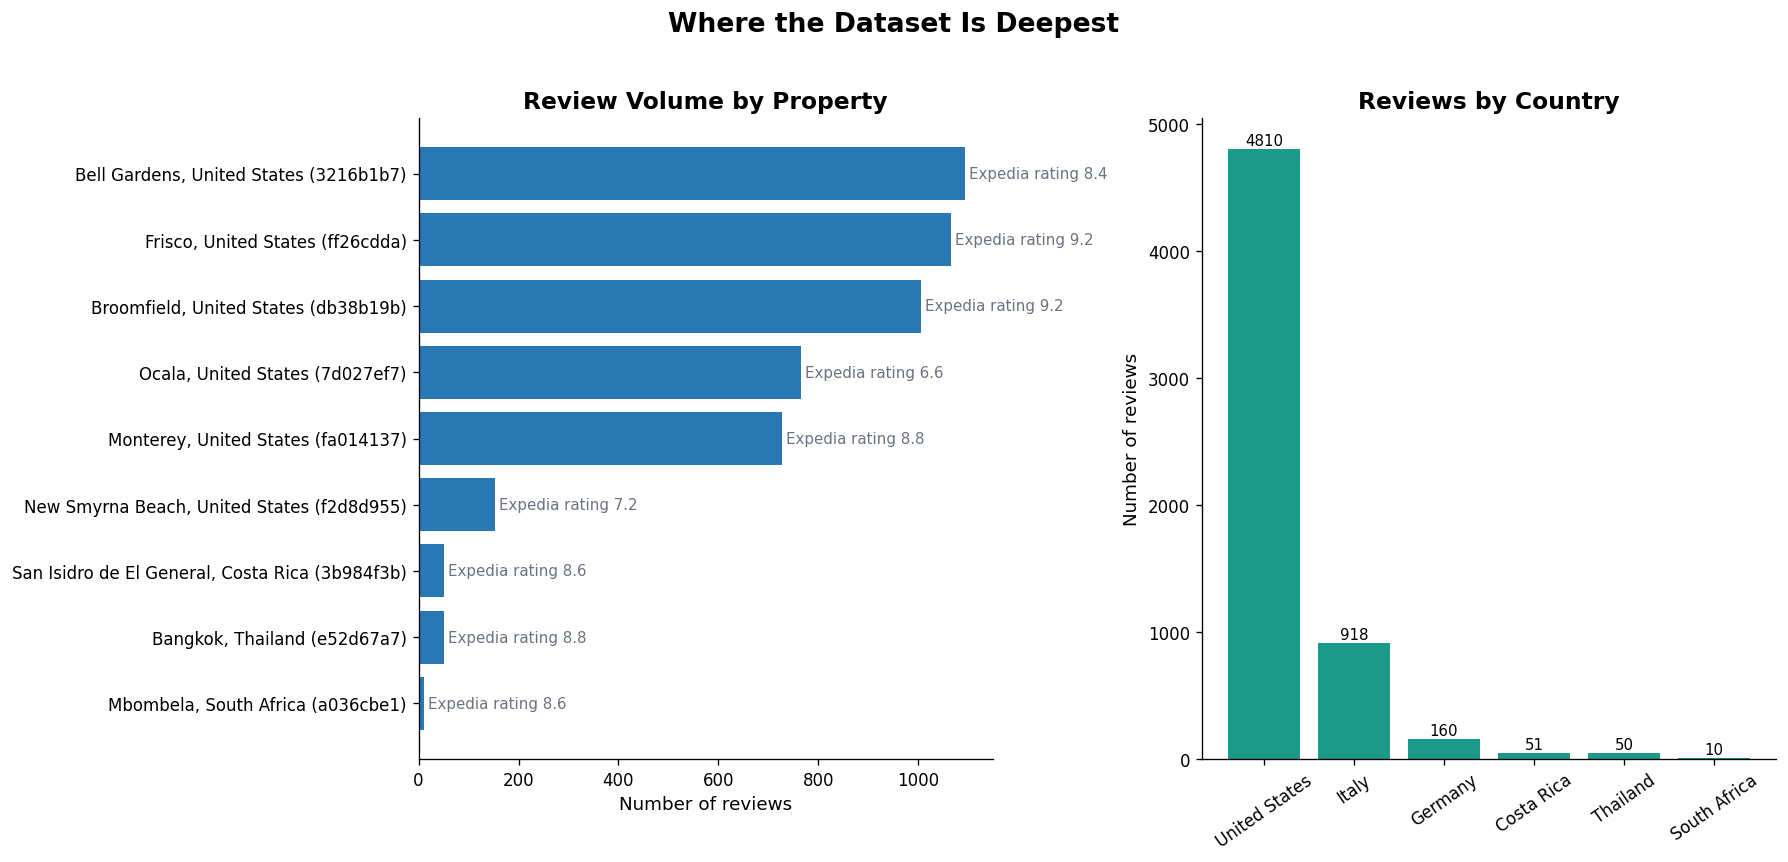

In [4]:
country_review_counts = (
    merged.groupby("country", as_index=False)
    .agg(properties=("eg_property_id", "nunique"), reviews=("eg_property_id", "size"))
    .sort_values("reviews", ascending=False)
)
country_review_counts.to_csv(OUTPUT_DIR / "country_review_counts.csv", index=False)

plot_df = property_summary.sort_values("review_count", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].barh(plot_df["property_label"], plot_df["review_count"], color=PALETTE["blue"])
axes[0].set_title("Review Volume by Property")
axes[0].set_xlabel("Number of reviews")
for idx, row in plot_df.reset_index(drop=True).iterrows():
    rating_text = f"Expedia rating {row['guestrating_avg_expedia']:.1f}" if pd.notna(row["guestrating_avg_expedia"]) else "No avg rating"
    axes[0].text(row["review_count"] + 8, idx, rating_text, va="center", fontsize=9, color=PALETTE["gray"])

axes[1].bar(country_review_counts["country"], country_review_counts["reviews"], color=PALETTE["teal"])
axes[1].set_title("Reviews by Country")
axes[1].set_ylabel("Number of reviews")
axes[1].tick_params(axis="x", rotation=35)
for idx, row in country_review_counts.reset_index(drop=True).iterrows():
    axes[1].text(idx, row["reviews"] + 25, str(int(row["reviews"])), ha="center", fontsize=9)

fig.suptitle("Where the Dataset Is Deepest", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
savefig(fig, "01_portfolio_overview")


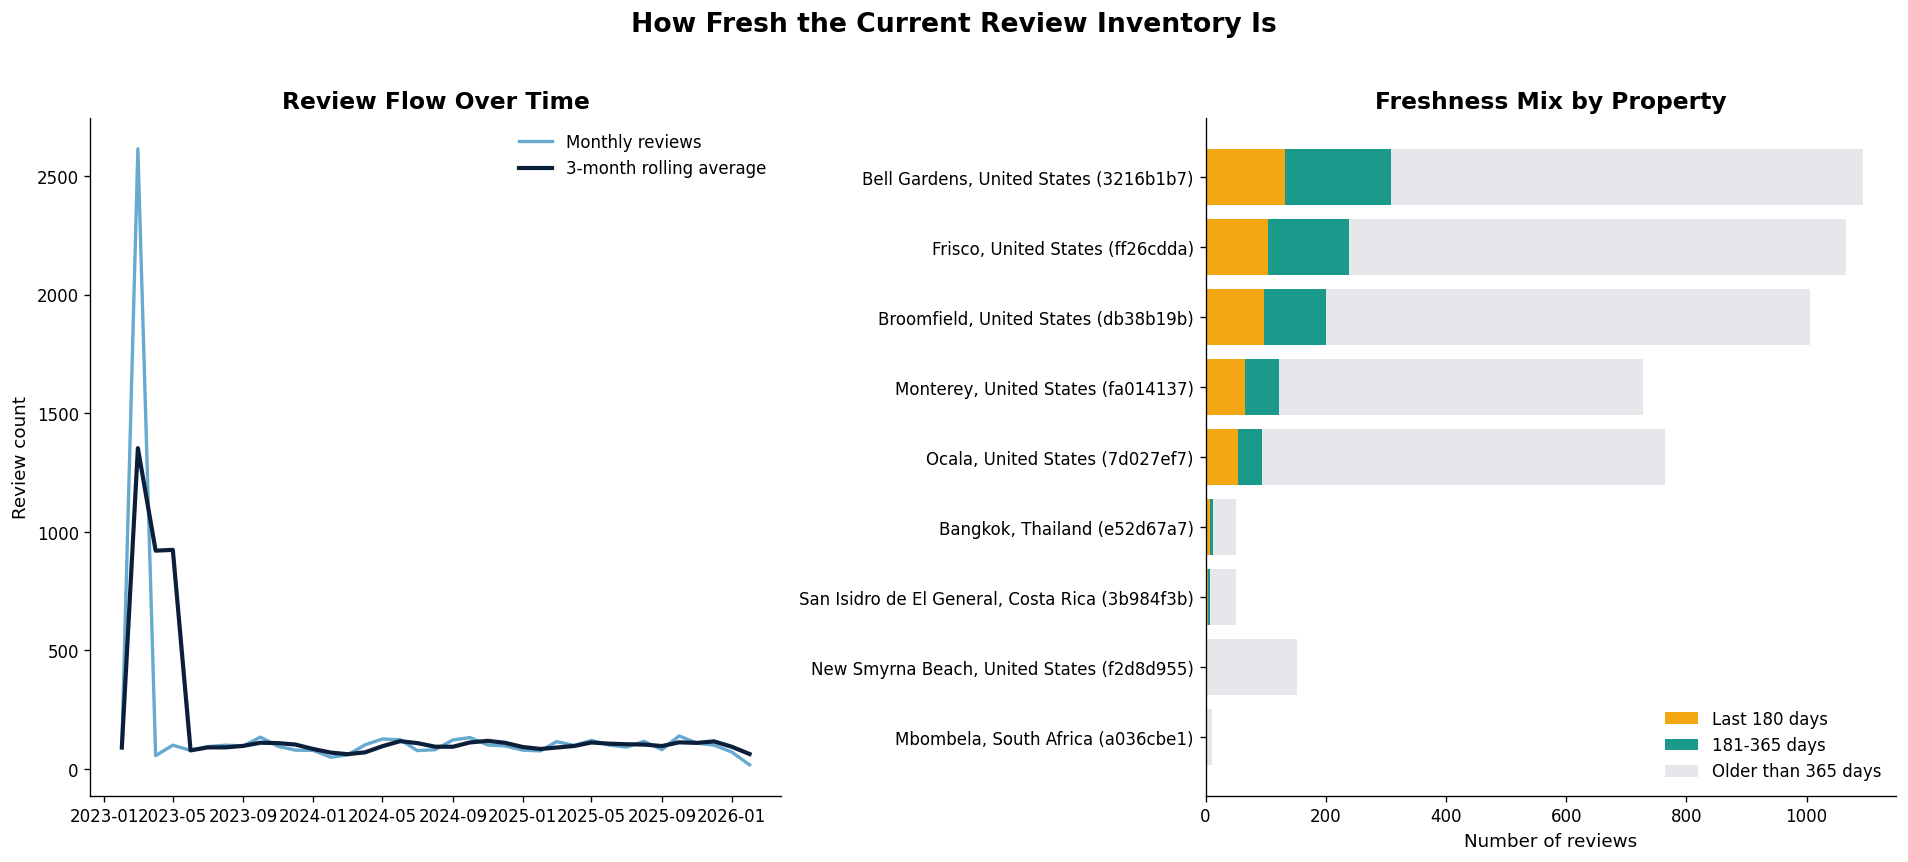

In [5]:
monthly_reviews = (
    merged.groupby("review_month", as_index=False)
    .agg(review_count=("eg_property_id", "size"))
    .sort_values("review_month")
)
monthly_reviews["rolling_3m"] = monthly_reviews["review_count"].rolling(3, min_periods=1).mean()
monthly_reviews.to_csv(OUTPUT_DIR / "monthly_reviews.csv", index=False)

recency_mix = property_summary.copy()
recency_mix["days_181_to_365"] = recency_mix["recent_365_reviews"] - recency_mix["recent_180_reviews"]
recency_mix["older_than_365"] = (
    recency_mix["review_count"] - recency_mix["recent_365_reviews"]
)
recency_mix = recency_mix.sort_values("recent_365_reviews", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].plot(monthly_reviews["review_month"], monthly_reviews["review_count"], color=PALETTE["sky"], linewidth=2, label="Monthly reviews")
axes[0].plot(monthly_reviews["review_month"], monthly_reviews["rolling_3m"], color=PALETTE["navy"], linewidth=2.5, label="3-month rolling average")
axes[0].set_title("Review Flow Over Time")
axes[0].set_ylabel("Review count")
axes[0].legend(frameon=False)

axes[1].barh(recency_mix["property_label"], recency_mix["recent_180_reviews"], color=PALETTE["gold"], label="Last 180 days")
axes[1].barh(
    recency_mix["property_label"],
    recency_mix["days_181_to_365"],
    left=recency_mix["recent_180_reviews"],
    color=PALETTE["teal"],
    label="181-365 days",
)
axes[1].barh(
    recency_mix["property_label"],
    recency_mix["older_than_365"],
    left=recency_mix["recent_365_reviews"],
    color=PALETTE["light_gray"],
    label="Older than 365 days",
)
axes[1].set_title("Freshness Mix by Property")
axes[1].set_xlabel("Number of reviews")
axes[1].legend(frameon=False, loc="lower right")

fig.suptitle("How Fresh the Current Review Inventory Is", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
savefig(fig, "02_review_freshness")


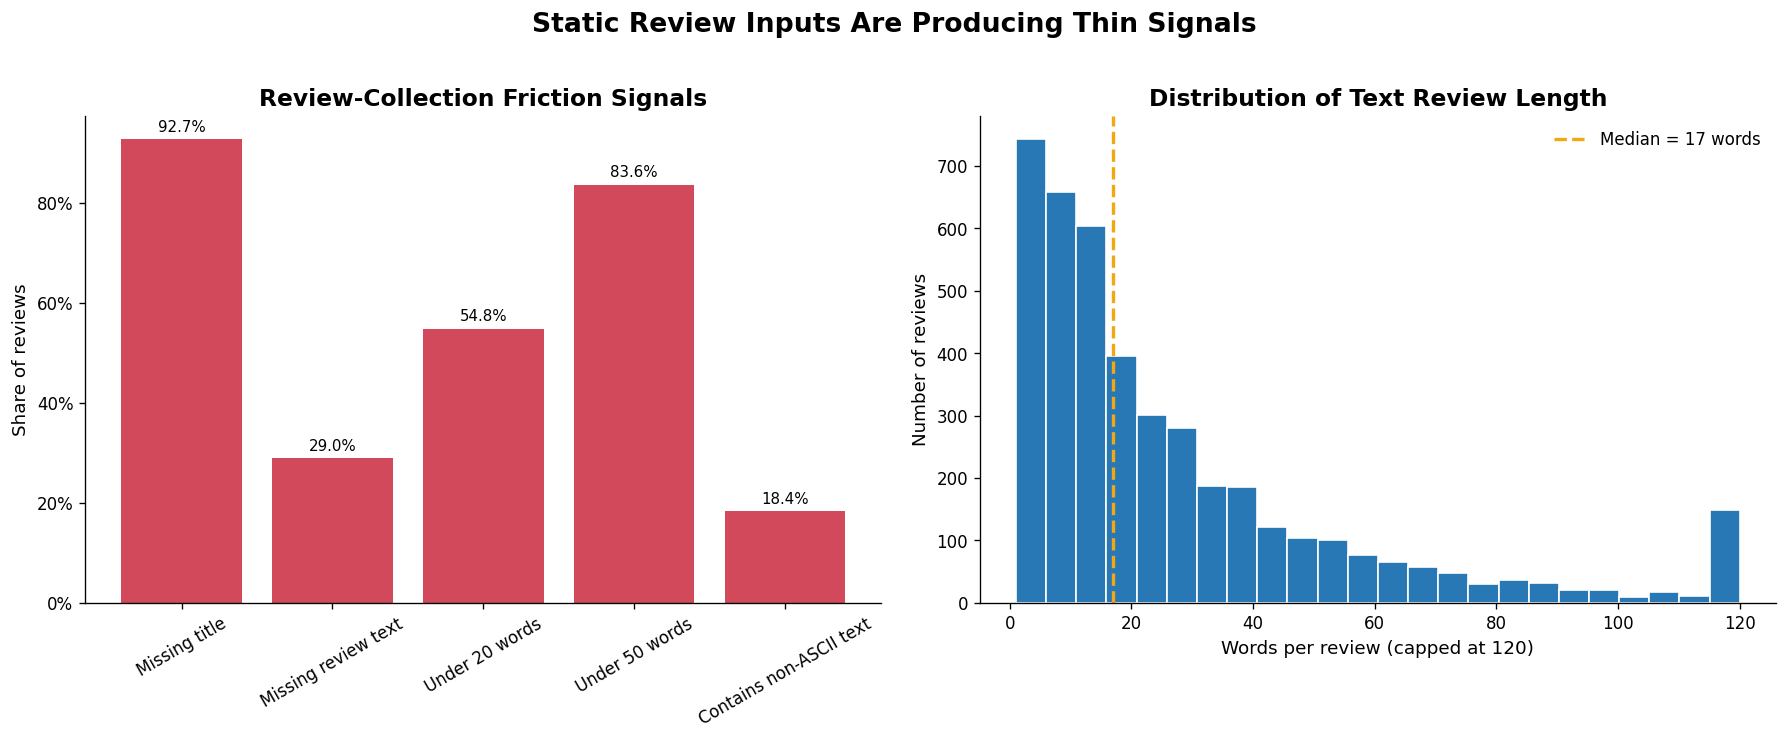

In [6]:
text_reviews = reviews.loc[reviews["has_text"]].copy()
completeness_metrics = pd.DataFrame(
    {
        "metric": [
            "Missing title",
            "Missing review text",
            "Under 20 words",
            "Under 50 words",
            "Contains non-ASCII text",
        ],
        "share": [
            1 - reviews["has_title"].mean(),
            1 - reviews["has_text"].mean(),
            text_reviews["under_20_words"].mean(),
            text_reviews["under_50_words"].mean(),
            text_reviews["non_ascii_text"].mean(),
        ],
    }
)
completeness_metrics.to_csv(OUTPUT_DIR / "text_completeness_metrics.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(completeness_metrics["metric"], completeness_metrics["share"], color=PALETTE["red"])
axes[0].set_title("Review-Collection Friction Signals")
axes[0].set_ylabel("Share of reviews")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].tick_params(axis="x", rotation=30)
for idx, row in completeness_metrics.reset_index(drop=True).iterrows():
    axes[0].text(idx, row["share"] + 0.015, pct(row["share"]), ha="center", fontsize=9)

capped_word_count = text_reviews["word_count"].clip(upper=120)
axes[1].hist(capped_word_count, bins=24, color=PALETTE["blue"], edgecolor="white")
axes[1].axvline(text_reviews["word_count"].median(), color=PALETTE["gold"], linestyle="--", linewidth=2, label=f"Median = {text_reviews['word_count'].median():.0f} words")
axes[1].set_title("Distribution of Text Review Length")
axes[1].set_xlabel("Words per review (capped at 120)")
axes[1].set_ylabel("Number of reviews")
axes[1].legend(frameon=False)

fig.suptitle("Static Review Inputs Are Producing Thin Signals", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
savefig(fig, "03_text_friction_and_length")


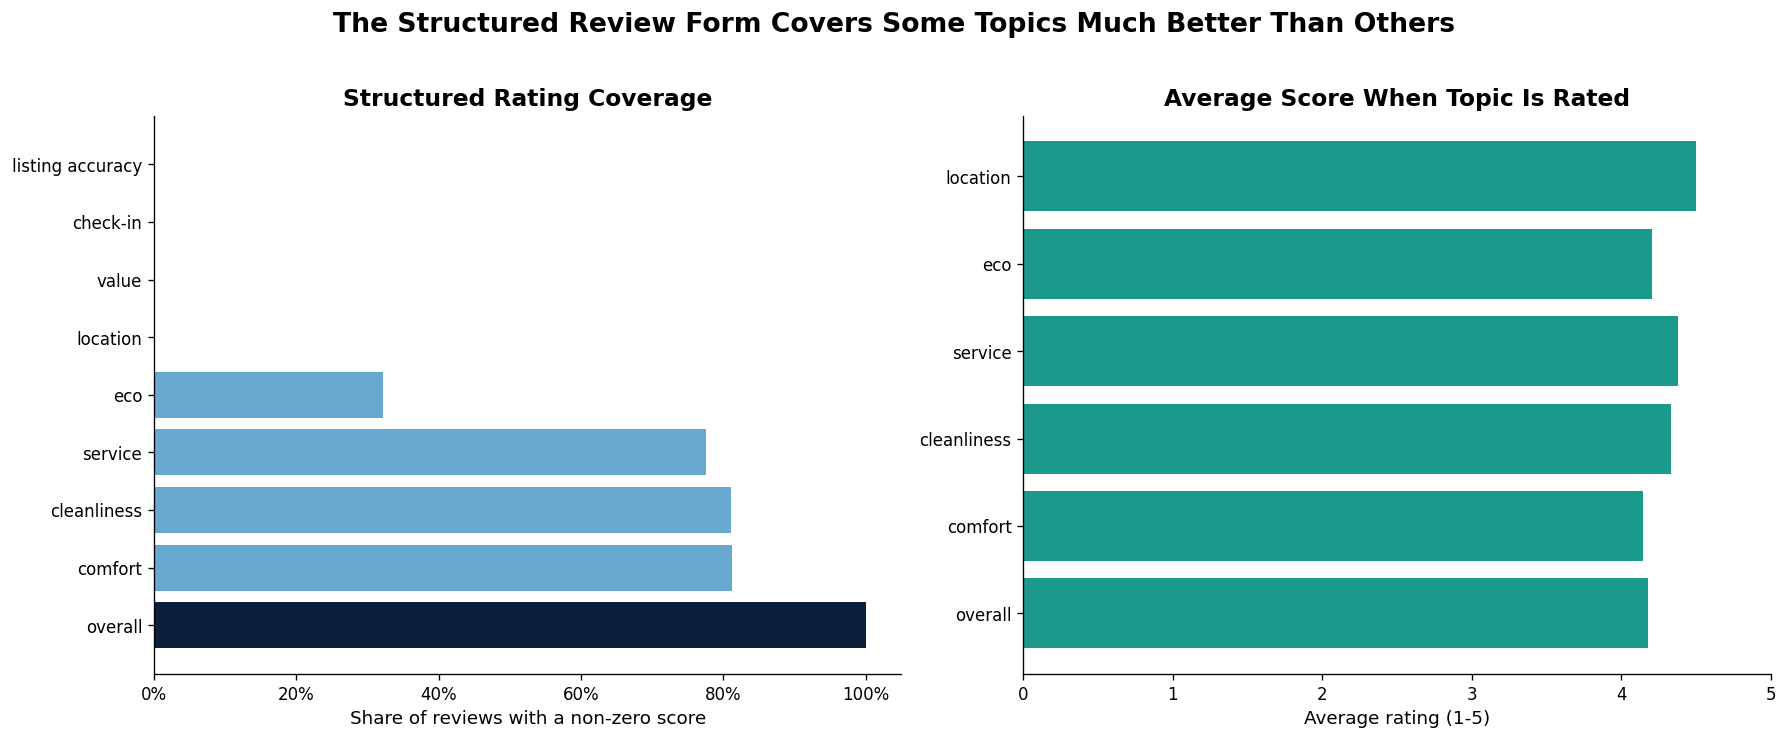

In [7]:
rating_topic_map = {
    "overall": ["rating_overall"],
    "cleanliness": ["rating_roomcleanliness"],
    "service": ["rating_service", "rating_communication"],
    "comfort": ["rating_roomcomfort", "rating_roomquality", "rating_roomamenitiesscore", "rating_hotelcondition"],
    "location": ["rating_convenienceoflocation", "rating_neighborhoodsatisfaction", "rating_location"],
    "value": ["rating_valueformoney"],
    "check-in": ["rating_checkin"],
    "listing accuracy": ["rating_onlinelisting"],
    "eco": ["rating_ecofriendliness"],
}

coverage_rows = []
for label, cols in rating_topic_map.items():
    coverage_rows.append(
        {
            "topic": label,
            "coverage_share": reviews[cols].gt(0).any(axis=1).mean(),
            "avg_score_when_present": reviews[cols].replace(0, np.nan).mean(axis=1).mean(),
        }
    )

rating_coverage = pd.DataFrame(coverage_rows).sort_values("coverage_share", ascending=False)
rating_coverage.to_csv(OUTPUT_DIR / "structured_rating_coverage.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(
    rating_coverage["topic"],
    rating_coverage["coverage_share"],
    color=[PALETTE["navy"] if topic == "overall" else PALETTE["sky"] for topic in rating_coverage["topic"]],
)
axes[0].set_title("Structured Rating Coverage")
axes[0].set_xlabel("Share of reviews with a non-zero score")
axes[0].xaxis.set_major_formatter(PercentFormatter(1))

axes[1].barh(rating_coverage["topic"], rating_coverage["avg_score_when_present"], color=PALETTE["teal"])
axes[1].set_title("Average Score When Topic Is Rated")
axes[1].set_xlabel("Average rating (1-5)")
axes[1].set_xlim(0, 5)

fig.suptitle("The Structured Review Form Covers Some Topics Much Better Than Others", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
savefig(fig, "04_structured_rating_coverage")


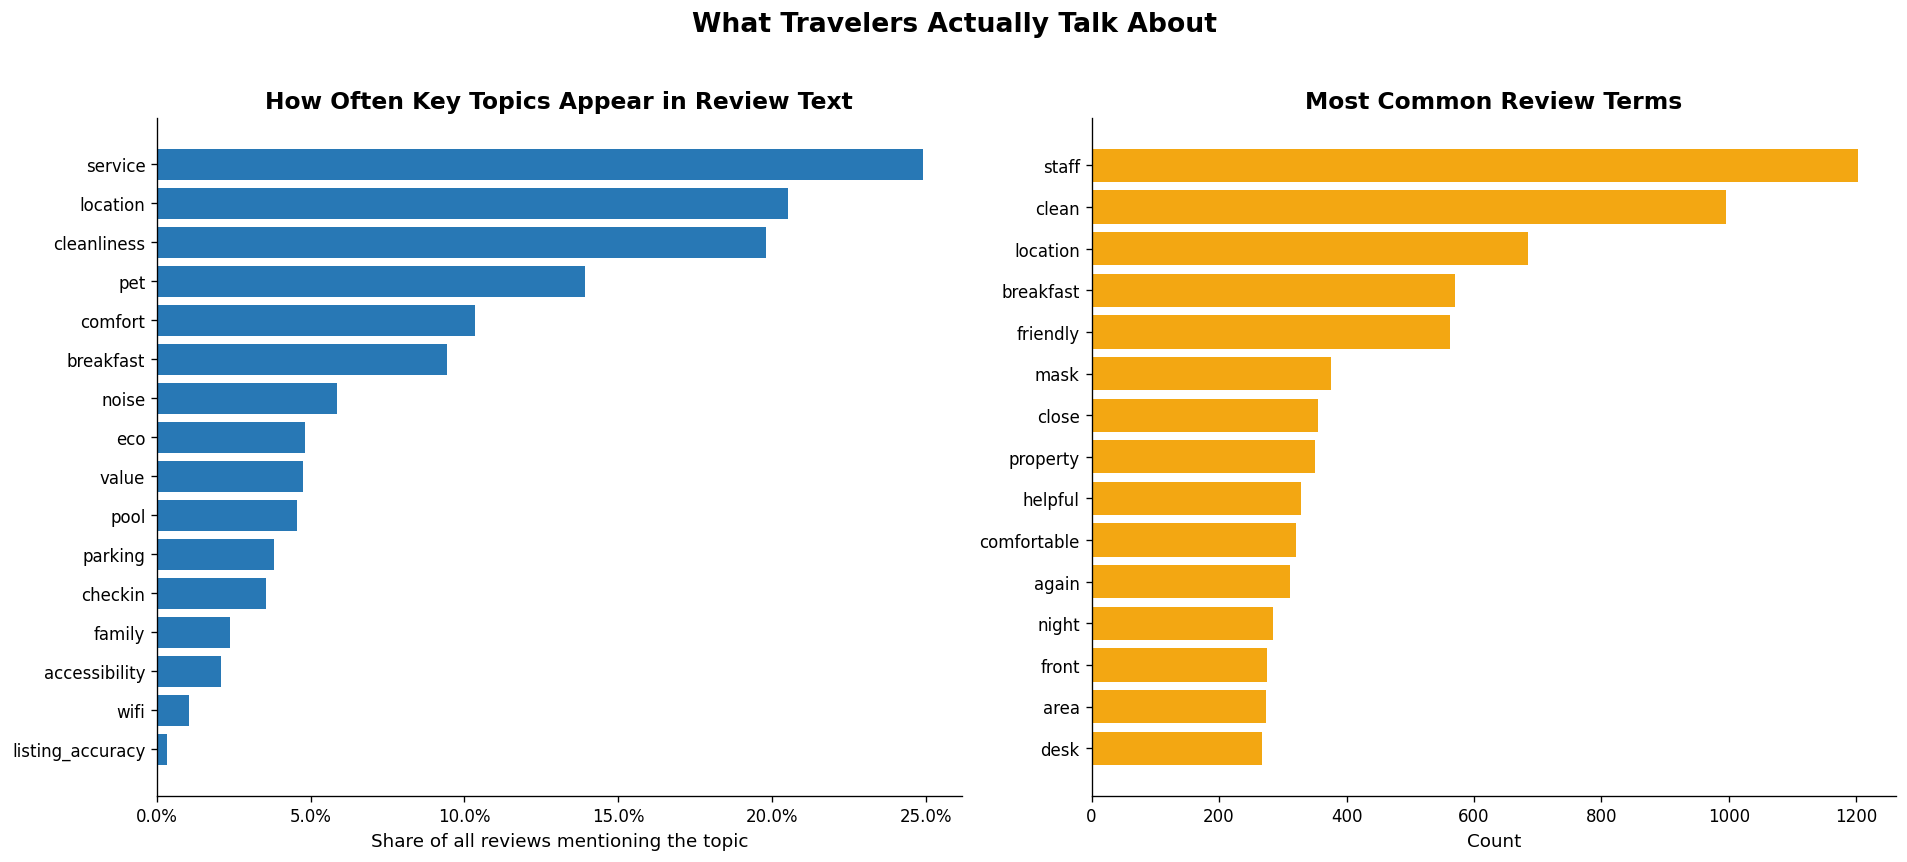

In [8]:
TOPIC_KEYWORDS = {
    "cleanliness": ["clean", "dirty", "smell", "odor", "mold", "filthy", "stain"],
    "service": ["staff", "service", "friendly", "helpful", "rude", "front desk", "front-desk"],
    "comfort": ["comfortable", "comfort", "bed", "sleep", "mattress", "pillow"],
    "location": ["location", "walk", "walking", "near", "close", "far", "distance", "safe", "unsafe"],
    "checkin": ["check in", "check-in", "checkin", "arrival"],
    "value": ["value", "worth", "price", "expensive", "overpriced", "cheap", "affordable"],
    "listing_accuracy": ["pictured", "photos", "advertised", "listing", "described", "description", "as shown", "as advertised"],
    "wifi": ["wifi", "wi-fi", "internet"],
    "parking": ["parking", "garage", "valet"],
    "breakfast": ["breakfast", "buffet", "coffee"],
    "pool": ["pool", "hot tub", "swim"],
    "noise": ["noise", "noisy", "quiet", "loud", "thin walls", "sleep"],
    "pet": ["pet", "pets", "dog", "dogs", "cat", "cats"],
    "family": ["kids", "kid", "family", "children", "child", "crib"],
    "accessibility": ["accessible", "wheelchair", "elevator", "stairs", "lift"],
    "eco": ["eco", "sustainable", "green", "recycle"],
}

for topic, keywords in TOPIC_KEYWORDS.items():
    reviews[f"topic_{topic}"] = reviews["clean_text"].apply(lambda text: bool_from_keywords(text, keywords))

topic_share = (
    pd.Series({topic: reviews[f"topic_{topic}"].mean() for topic in TOPIC_KEYWORDS})
    .sort_values(ascending=False)
    .rename("share")
    .reset_index()
    .rename(columns={"index": "topic"})
)
topic_share.to_csv(OUTPUT_DIR / "topic_mention_share.csv", index=False)

common_terms = Counter()
stop_words = {
    "hotel", "room", "rooms", "great", "good", "nice", "stay", "place", "really", "also", "very",
    "were", "with", "from", "that", "this", "have", "would", "there", "about", "after", "their",
    "your", "only", "when", "been", "will", "them", "they", "just", "into", "than", "didn",
}
for text in reviews["clean_text"]:
    for token in re.findall(r"[a-z]{4,}", text):
        if token not in stop_words:
            common_terms[token] += 1

common_terms_df = pd.DataFrame(common_terms.most_common(40), columns=["term", "count"])
common_terms_df.to_csv(OUTPUT_DIR / "common_terms.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(topic_share["topic"], topic_share["share"], color=PALETTE["blue"])
axes[0].set_title("How Often Key Topics Appear in Review Text")
axes[0].set_xlabel("Share of all reviews mentioning the topic")
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].invert_yaxis()

top_terms = common_terms_df.head(15).sort_values("count", ascending=True)
axes[1].barh(top_terms["term"], top_terms["count"], color=PALETTE["gold"])
axes[1].set_title("Most Common Review Terms")
axes[1].set_xlabel("Count")

fig.suptitle("What Travelers Actually Talk About", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
savefig(fig, "05_topic_frequency_and_common_terms")


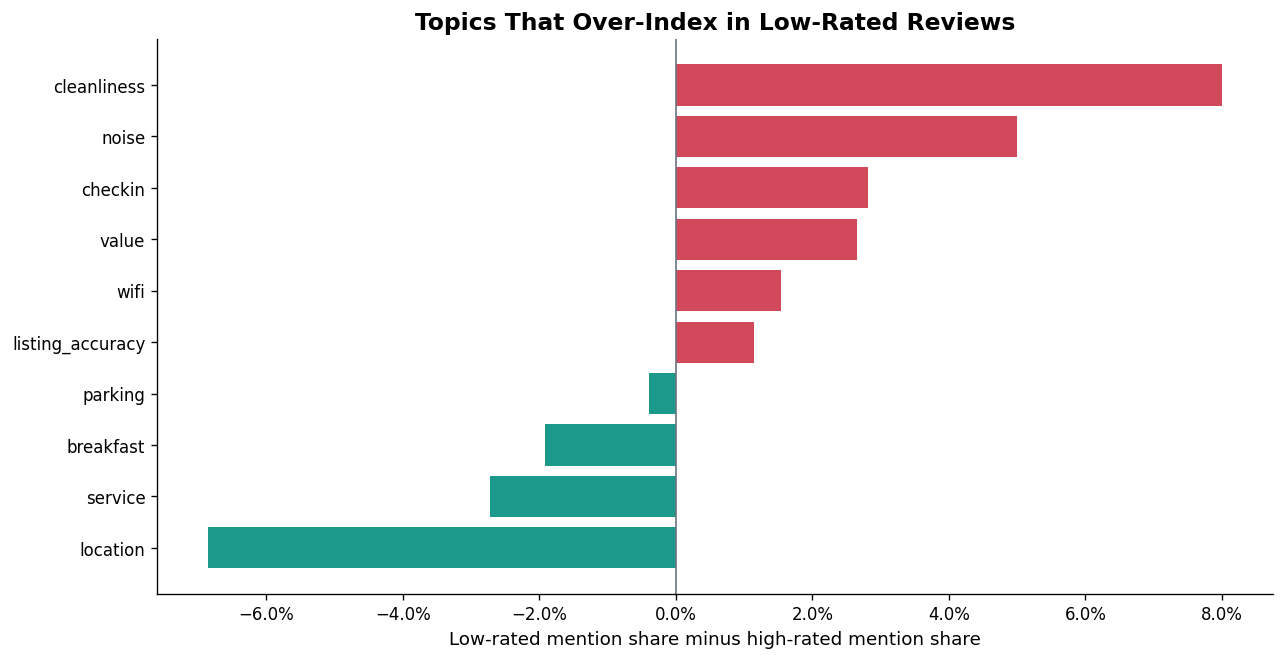

In [9]:
rated_reviews = reviews.dropna(subset=["overall_rating"]).copy()
low_reviews = rated_reviews["overall_rating"] <= 2
high_reviews = rated_reviews["overall_rating"] >= 4

pain_point_rows = []
comparison_topics = ["cleanliness", "service", "location", "checkin", "value", "wifi", "parking", "breakfast", "noise", "listing_accuracy"]
for topic in comparison_topics:
    col = f"topic_{topic}"
    low_share = rated_reviews.loc[low_reviews, col].mean()
    high_share = rated_reviews.loc[high_reviews, col].mean()
    pain_point_rows.append(
        {
            "topic": topic,
            "low_rating_share": low_share,
            "high_rating_share": high_share,
            "gap": low_share - high_share,
        }
    )

pain_point_df = pd.DataFrame(pain_point_rows).sort_values("gap", ascending=True)
pain_point_df.to_csv(OUTPUT_DIR / "low_vs_high_topic_gap.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(pain_point_df["topic"], pain_point_df["gap"], color=np.where(pain_point_df["gap"] >= 0, PALETTE["red"], PALETTE["teal"]))
ax.axvline(0, color=PALETTE["gray"], linewidth=1)
ax.set_title("Topics That Over-Index in Low-Rated Reviews")
ax.set_xlabel("Low-rated mention share minus high-rated mention share")
ax.xaxis.set_major_formatter(PercentFormatter(1))
savefig(fig, "06_pain_point_topics")


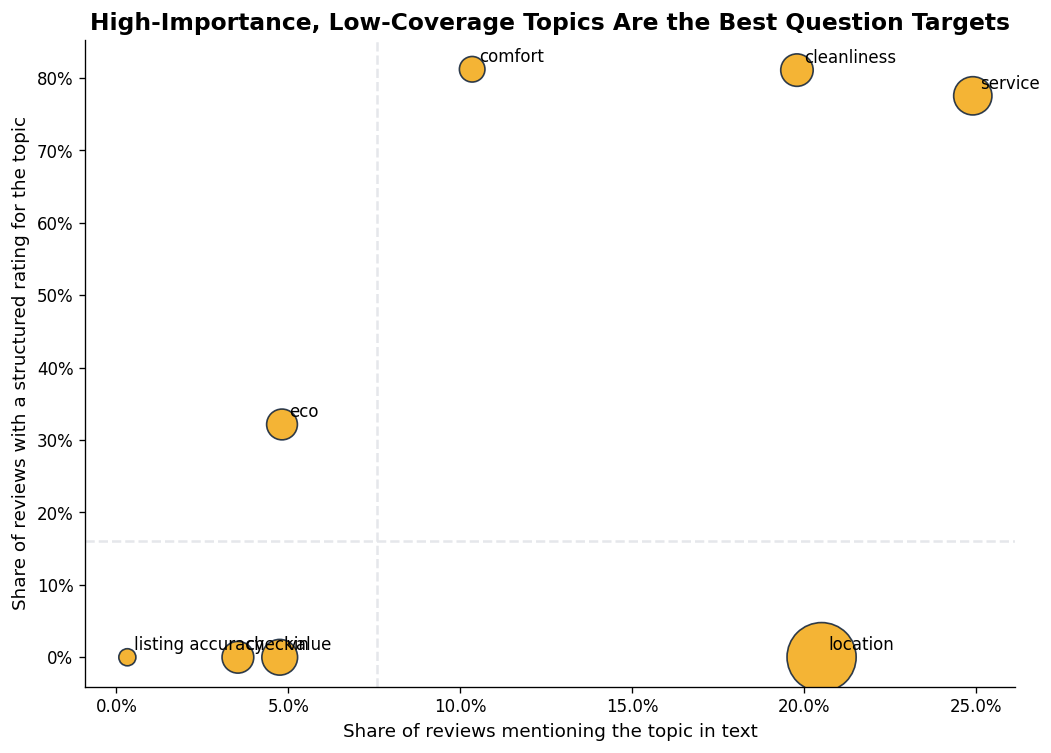

In [10]:
structured_coverage_for_topics = {
    "cleanliness": reviews[["rating_roomcleanliness"]].gt(0).any(axis=1).mean(),
    "service": reviews[["rating_service", "rating_communication"]].gt(0).any(axis=1).mean(),
    "comfort": reviews[["rating_roomcomfort", "rating_roomquality", "rating_roomamenitiesscore", "rating_hotelcondition"]].gt(0).any(axis=1).mean(),
    "location": reviews[["rating_convenienceoflocation", "rating_neighborhoodsatisfaction", "rating_location"]].gt(0).any(axis=1).mean(),
    "value": reviews[["rating_valueformoney"]].gt(0).any(axis=1).mean(),
    "checkin": reviews[["rating_checkin"]].gt(0).any(axis=1).mean(),
    "listing_accuracy": reviews[["rating_onlinelisting"]].gt(0).any(axis=1).mean(),
    "eco": reviews[["rating_ecofriendliness"]].gt(0).any(axis=1).mean(),
}

importance_vs_coverage = pd.DataFrame(
    {
        "topic": list(structured_coverage_for_topics.keys()),
        "text_importance": [reviews[f"topic_{topic}"].mean() for topic in structured_coverage_for_topics],
        "structured_coverage": list(structured_coverage_for_topics.values()),
    }
)
importance_vs_coverage["gap_score"] = importance_vs_coverage["text_importance"] * (1 - importance_vs_coverage["structured_coverage"])
importance_vs_coverage = importance_vs_coverage.sort_values("gap_score", ascending=False)
importance_vs_coverage.to_csv(OUTPUT_DIR / "importance_vs_coverage.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 7))
sizes = 8000 * (importance_vs_coverage["gap_score"] + 0.01)
ax.scatter(
    importance_vs_coverage["text_importance"],
    importance_vs_coverage["structured_coverage"],
    s=sizes,
    color=PALETTE["gold"],
    edgecolor=PALETTE["navy"],
    alpha=0.85,
)
for _, row in importance_vs_coverage.iterrows():
    ax.text(
        row["text_importance"] + 0.002,
        row["structured_coverage"] + 0.01,
        row["topic"].replace("_", " "),
        fontsize=10,
    )

ax.axvline(importance_vs_coverage["text_importance"].median(), color=PALETTE["light_gray"], linestyle="--")
ax.axhline(importance_vs_coverage["structured_coverage"].median(), color=PALETTE["light_gray"], linestyle="--")
ax.set_title("High-Importance, Low-Coverage Topics Are the Best Question Targets")
ax.set_xlabel("Share of reviews mentioning the topic in text")
ax.set_ylabel("Share of reviews with a structured rating for the topic")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
savefig(fig, "07_importance_vs_coverage")


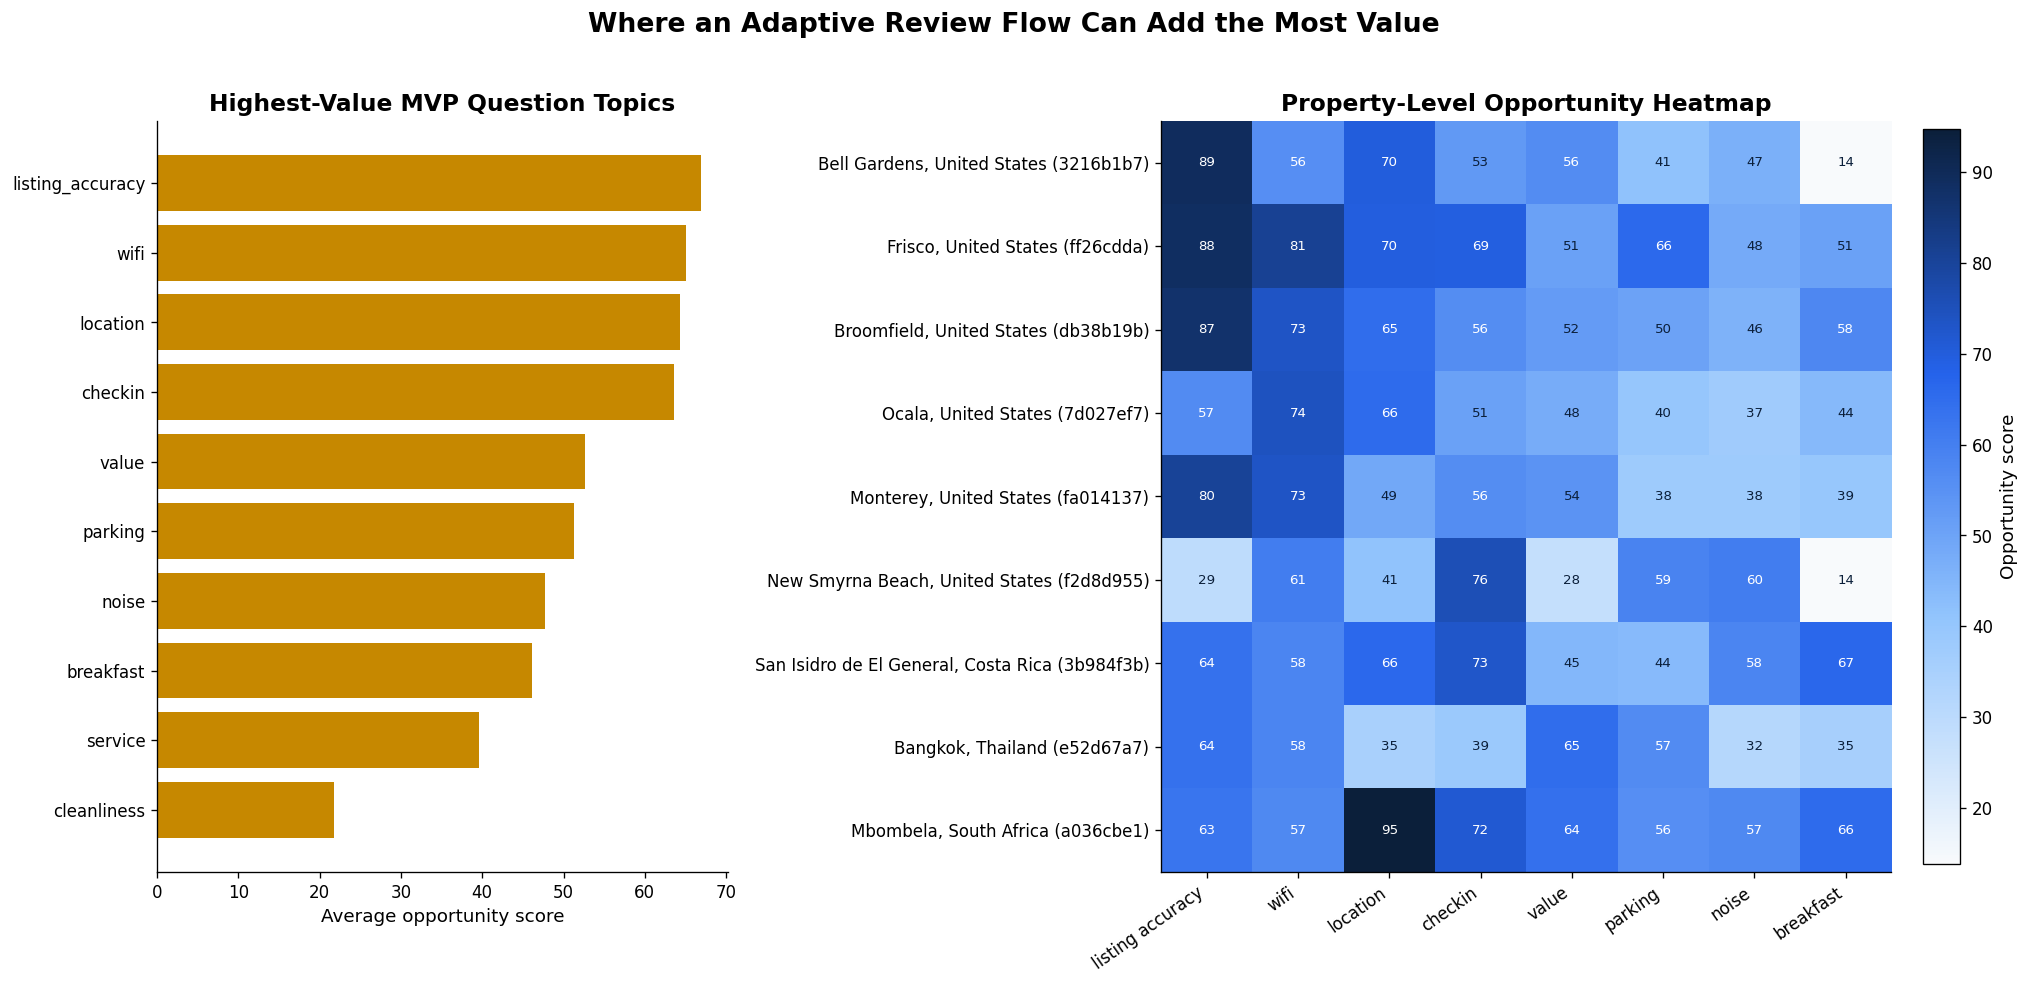

## Recommended First Questions by Property

,eg_property_id,property_label,city,country,question_1,score_1,topic_1,question_2,score_2,topic_2
9,e52d67a758ce4ad0229aacc97e5dfe89984c384c51a70208f9e0cc65c9cd4676,"Bangkok, Thailand (e52d67a7)",Bangkok,Thailand,Did the stay feel like good value for the price you paid?,64.892,value,Did the room and amenities match what the listing promised?,63.655,listing_accuracy
1,3216b1b7885bffdb336265a8de7322ba0cd477cfb3d4f99d19acf488f76a1941,"Bell Gardens, United States (3216b1b7)",Bell Gardens,United States,Did the room and amenities match what the listing promised?,89.189,listing_accuracy,How convenient and walkable did the location feel during your stay?,70.021,location
6,9a0043fd4258a1286db1e253ca591662b3aac849da12d0d4f67e08b8f59be65f,"Bochum, Germany (9a0043fd)",Bochum,Germany,How convenient and walkable did the location feel during your stay?,100.000,location,Was check-in smooth and clear when you arrived?,75.541,checkin
8,db38b19b897dbece3e34919c662b3fd66d23b615395d11fb69264dd3a9b17723,"Broomfield, United States (db38b19b)",Broomfield,United States,Did the room and amenities match what the listing promised?,87.037,listing_accuracy,"How reliable was the Wi-Fi for browsing, streaming, or work?",73.288,wifi
3,5f5a0cd8662f0ddf297f2d27358f680daab5d3ac22fd45a4e1c3c3ec2c101a12,"Freudenstadt, Germany (5f5a0cd8)",Freudenstadt,Germany,How convenient and walkable did the location feel during your stay?,94.676,location,How helpful and responsive was the staff during your stay?,94.527,service
12,ff26cdda236b233f7c481f0e896814075ac6bed335e162e0ff01d5491343f838,"Frisco, United States (ff26cdda)",Frisco,United States,Did the room and amenities match what the listing promised?,88.480,listing_accuracy,"How reliable was the Wi-Fi for browsing, streaming, or work?",81.019,wifi
7,a036cbe1d9fbf9cba088075d1b4d966ee871df55aa4a58ba0da23c116c499052,"Mbombela, South Africa (a036cbe1)",Mbombela,South Africa,How convenient and walkable did the location feel during your stay?,94.750,location,How helpful and responsive was the staff during your stay?,94.601,service
11,fa014137b3ea9af6a90c0a86a1d099e46f7e56d6eb33db1ad1ec4bdac68c3caa,"Monterey, United States (fa014137)",Monterey,United States,Did the room and amenities match what the listing promised?,80.238,listing_accuracy,"How reliable was the Wi-Fi for browsing, streaming, or work?",73.471,wifi
10,f2d8d9557208d58577e9df7ff34e42bf86fb5b10fdfae0c3040d14c374a2a2b9,"New Smyrna Beach, United States (f2d8d955)",New Smyrna Beach,United States,Was check-in smooth and clear when you arrived?,75.541,checkin,"How reliable was the Wi-Fi for browsing, streaming, or work?",60.572,wifi
4,7d027ef72c02eaa17af3c993fd5dba50d17b41a6280389a46c13c7e2c32a5b06,"Ocala, United States (7d027ef7)",Ocala,United States,"How reliable was the Wi-Fi for browsing, streaming, or work?",74.300,wifi,How convenient and walkable did the location feel during your stay?,65.579,location


In [11]:
mvp_topics = [
    "checkin",
    "listing_accuracy",
    "location",
    "value",
    "wifi",
    "parking",
    "breakfast",
    "noise",
    "cleanliness",
    "service",
]

business_prior = {
    "checkin": 1.00,
    "listing_accuracy": 0.95,
    "location": 0.90,
    "value": 0.85,
    "wifi": 0.85,
    "parking": 0.75,
    "breakfast": 0.75,
    "noise": 0.72,
    "cleanliness": 0.80,
    "service": 0.78,
}

question_templates = {
    "checkin": "Was check-in smooth and clear when you arrived?",
    "listing_accuracy": "Did the room and amenities match what the listing promised?",
    "location": "How convenient and walkable did the location feel during your stay?",
    "value": "Did the stay feel like good value for the price you paid?",
    "wifi": "How reliable was the Wi-Fi for browsing, streaming, or work?",
    "parking": "How easy was parking, and were there any extra fees or surprises?",
    "breakfast": "If you used breakfast, how good and convenient was it?",
    "noise": "How quiet was the room at night?",
    "cleanliness": "How clean did the room and bathroom feel when you arrived?",
    "service": "How helpful and responsive was the staff during your stay?",
}

topic_to_rating_columns = {
    "cleanliness": ["rating_roomcleanliness"],
    "service": ["rating_service", "rating_communication"],
    "location": ["rating_convenienceoflocation", "rating_neighborhoodsatisfaction", "rating_location"],
    "value": ["rating_valueformoney"],
    "checkin": ["rating_checkin"],
    "listing_accuracy": ["rating_onlinelisting"],
}


def topic_relevance(property_row, topic):
    amenity_text = property_row["amenity_text"]
    pet_policy = property_row["pet_policy_clean"]
    children_policy = property_row["children_policy_clean"]

    if topic in {"checkin", "listing_accuracy", "location", "value", "cleanliness", "service", "noise"}:
        return 1.0
    if topic == "wifi":
        return 1.0 if any(token in amenity_text for token in ["wifi", "internet"]) else 0.70
    if topic == "parking":
        return 1.0 if "parking" in amenity_text else 0.20
    if topic == "breakfast":
        return 1.0 if "breakfast" in amenity_text else 0.20
    if topic == "pet":
        if "not allowed" in pet_policy:
            return 0.10
        return 1.0 if "pet" in pet_policy or "dog" in pet_policy else 0.35
    if topic == "family":
        return 1.0 if "children are welcome" in children_policy or "crib" in amenity_text else 0.60
    return 0.50


observed_share = {topic: reviews[f"topic_{topic}"].mean() for topic in mvp_topics}
max_observed = max(observed_share.values())
blended_importance = {
    topic: 0.60 * business_prior[topic] + 0.40 * (observed_share[topic] / max_observed if max_observed else 0)
    for topic in mvp_topics
}

property_rows = []
max_review_count = property_summary["review_count"].max()

for property_id, property_reviews in reviews.groupby("eg_property_id"):
    property_meta = description.loc[description["eg_property_id"] == property_id].iloc[0]
    recent_reviews = property_reviews.loc[property_reviews["acquisition_date"] >= recent_365_cutoff]
    property_volume_factor = 0.7 + 0.3 * (len(property_reviews) / max_review_count)

    for topic in mvp_topics:
        topic_col = f"topic_{topic}"
        text_recent_share = recent_reviews[topic_col].mean() if len(recent_reviews) else 0.0

        rating_cols = topic_to_rating_columns.get(topic, [])
        structured_recent_share = 0.0
        structured_all_signal = pd.Series(False, index=property_reviews.index)
        if rating_cols:
            structured_recent_share = (
                recent_reviews[rating_cols].gt(0).any(axis=1).mean() if len(recent_reviews) else 0.0
            )
            structured_all_signal = property_reviews[rating_cols].gt(0).any(axis=1)

        all_signal = property_reviews[topic_col] | structured_all_signal
        recent_signal_share = max(text_recent_share, structured_recent_share)

        if all_signal.any():
            last_signal_date = property_reviews.loc[all_signal, "acquisition_date"].max()
            days_since_last_signal = (analysis_end - last_signal_date).days
        else:
            days_since_last_signal = (analysis_end - property_reviews["acquisition_date"].min()).days

        staleness = min(days_since_last_signal / 365, 1.0)
        coverage_gap = 1 - recent_signal_share
        relevance = topic_relevance(property_meta, topic)
        raw_score = blended_importance[topic] * (0.55 * coverage_gap + 0.45 * staleness) * property_volume_factor * relevance

        property_rows.append(
            {
                "eg_property_id": property_id,
                "property_label": property_meta["property_label"],
                "city": property_meta["city"],
                "country": property_meta["country"],
                "topic": topic,
                "observed_share": observed_share[topic],
                "importance": blended_importance[topic],
                "recent_signal_share": recent_signal_share,
                "days_since_last_signal": days_since_last_signal,
                "staleness": staleness,
                "relevance": relevance,
                "score_raw": raw_score,
                "recommended_question": question_templates[topic],
            }
        )

opportunity_df = pd.DataFrame(property_rows)
opportunity_df["score"] = 100 * opportunity_df["score_raw"] / opportunity_df["score_raw"].max()
opportunity_df = opportunity_df.sort_values(["eg_property_id", "score"], ascending=[True, False])
opportunity_df.to_csv(OUTPUT_DIR / "property_question_opportunities_long.csv", index=False)

top_questions = (
    opportunity_df.groupby("eg_property_id")
    .head(2)
    .assign(rank=lambda df: df.groupby("eg_property_id").cumcount() + 1)
)

top_questions_wide = (
    top_questions.pivot(index=["eg_property_id", "property_label", "city", "country"], columns="rank", values=["topic", "score", "recommended_question"])
    .sort_index(axis=1, level=1)
)
top_questions_wide.columns = ["_".join(map(str, col)).replace("recommended_question", "question") for col in top_questions_wide.columns]
top_questions_wide = top_questions_wide.reset_index().sort_values("property_label")
top_questions_wide.to_csv(OUTPUT_DIR / "recommended_questions_by_property.csv", index=False)

global_topic_priority = (
    opportunity_df.groupby("topic", as_index=False)
    .agg(mean_score=("score", "mean"))
    .sort_values("mean_score", ascending=False)
)
global_topic_priority.to_csv(OUTPUT_DIR / "global_topic_priority.csv", index=False)

heatmap_topics = global_topic_priority["topic"].head(8).tolist()
heatmap_df = (
    opportunity_df.loc[opportunity_df["topic"].isin(heatmap_topics)]
    .pivot(index="property_label", columns="topic", values="score")
    .reindex(columns=heatmap_topics)
)
heatmap_df = heatmap_df.loc[property_summary.sort_values("review_count", ascending=False)["property_label"]]
heatmap_df.to_csv(OUTPUT_DIR / "opportunity_heatmap_matrix.csv")

fig, axes = plt.subplots(1, 2, figsize=(17, 8), gridspec_kw={"width_ratios": [1, 1.4]})

axes[0].barh(global_topic_priority["topic"], global_topic_priority["mean_score"], color=PALETTE["dark_gold"])
axes[0].set_title("Highest-Value MVP Question Topics")
axes[0].set_xlabel("Average opportunity score")
axes[0].invert_yaxis()

cmap = LinearSegmentedColormap.from_list("expedia_heat", ["#F8FAFC", "#93C5FD", "#2563EB", "#0B1F3A"])
im = axes[1].imshow(heatmap_df.values, aspect="auto", cmap=cmap)
axes[1].set_title("Property-Level Opportunity Heatmap")
axes[1].set_xticks(np.arange(len(heatmap_df.columns)))
axes[1].set_xticklabels([label.replace("_", " ") for label in heatmap_df.columns], rotation=35, ha="right")
axes[1].set_yticks(np.arange(len(heatmap_df.index)))
axes[1].set_yticklabels(heatmap_df.index)
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]
        axes[1].text(j, i, f"{value:.0f}", ha="center", va="center", color="white" if value > 55 else PALETTE["navy"], fontsize=8)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Opportunity score")

fig.suptitle("Where an Adaptive Review Flow Can Add the Most Value", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
savefig(fig, "08_question_opportunity_map")

display(Markdown("## Recommended First Questions by Property"))
display(top_questions_wide)


In [12]:
top_global_topics = ", ".join(global_topic_priority["topic"].head(5).str.replace("_", " "))
high_gap_topics = ", ".join(importance_vs_coverage["topic"].head(4).str.replace("_", " "))

summary_markdown = (
    f"## MVP Takeaways\n\n"
    f"- **The dataset is deep enough to build a credible MVP**: 13 properties and {len(reviews):,} reviews across a three-year span.\n"
    f"- **Static review capture is clearly thin**: {pct(1 - reviews['has_title'].mean())} of reviews have no title, {pct(1 - reviews['has_text'].mean())} have no text, and the median text review is only {int(text_reviews['word_count'].median())} words.\n"
    f"- **Structured coverage is uneven**: cleanliness and service are fairly well covered, but some of the most decision-relevant topics remain sparse or empty.\n"
    f"- **The biggest blind spots are topics like {high_gap_topics}**, where traveler importance is not matched by structured coverage.\n"
    f"- **For the MVP, the highest-value question areas are {top_global_topics}**.\n"
    f"- **The product story should be freshness + precision**: ask the guest one question that closes the most valuable information gap for that specific property."
)

display(Markdown(summary_markdown))


## MVP Takeaways

- **The dataset is deep enough to build a credible MVP**: 13 properties and 5,999 reviews across a three-year span.
- **Static review capture is clearly thin**: 92.7% of reviews have no title, 29.0% have no text, and the median text review is only 17 words.
- **Structured coverage is uneven**: cleanliness and service are fairly well covered, but some of the most decision-relevant topics remain sparse or empty.
- **The biggest blind spots are topics like location, service, value, cleanliness**, where traveler importance is not matched by structured coverage.
- **For the MVP, the highest-value question areas are listing accuracy, wifi, location, checkin, value**.
- **The product story should be freshness + precision**: ask the guest one question that closes the most valuable information gap for that specific property.

## Suggested Slide Usage

The saved figures map cleanly to a pitch deck:

- `01_portfolio_overview`: quick data orientation
- `02_review_freshness`: evidence that review signals go stale
- `03_text_friction_and_length`: why static prompts underperform
- `04_structured_rating_coverage`: proof of topic coverage gaps
- `05_topic_frequency_and_common_terms`: what users naturally care about
- `06_pain_point_topics`: what shows up in bad experiences
- `07_importance_vs_coverage`: strongest problem statement visual
- `08_question_opportunity_map`: strongest MVP / product-strategy visual

If you want, the next step can be turning this analysis directly into:

1. an MVP question-selection algorithm,
2. a property-level JSON/API payload for the frontend, or
3. a slide-ready narrative with chart callouts.
